In [1]:
## imports

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LightSource

from mpl_toolkits.mplot3d import Axes3D

import seaborn as sns

from IPython.display import HTML

In [3]:
## details

## todo

#### % try to code on own using alorithm
#### % collect documentation and tutorials 
#### % use a library to retry

### Benchmark functions

- [bird functions](#bird-function)

#### bird function

In [4]:
### bird function for benchmarking

def bird_2d(x, y):
    return np.sin(x) * (np.exp(1 - np.cos(y)) ** 2) + np.cos(y) * (np.exp(1 - np.sin(x))**2) + ((x-y)**2)
     

In [5]:
x = np.arange(-10, 10, 0.05)
y = np.arange(-10, 10, 0.05)
X, Y = np.meshgrid(x, y)
Z = bird_2d(X, Y)

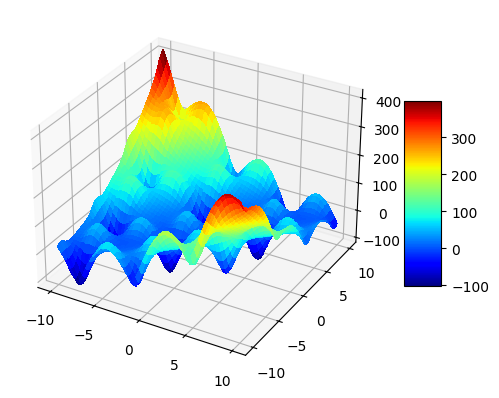

In [6]:

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the surface.
surf = ax.plot_surface(X, Y, Z, cmap=plt.cm.jet,
                       linewidth=0, antialiased=False)

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

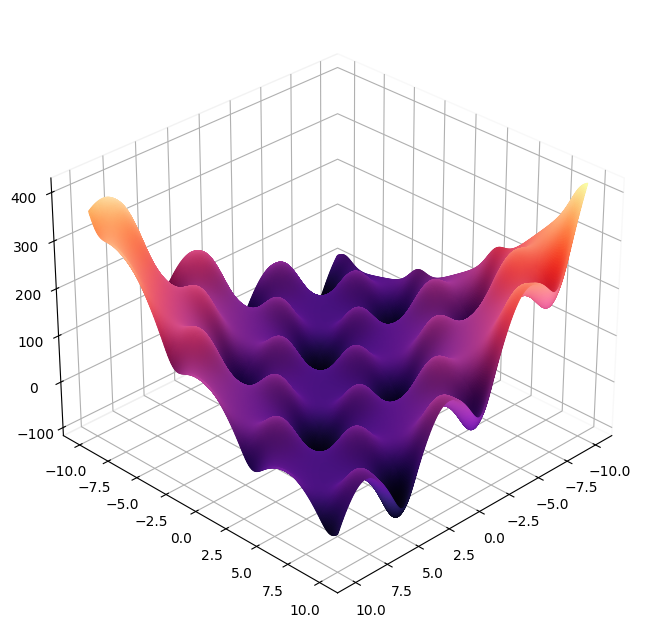

In [7]:
# Create a LightSource to give it a 3D "material" feel
ls = LightSource(azdeg=315, altdeg=45)

# Shade the data
# we use 'terrain' or 'magma' for a more professional look than 'jet'
rgb = ls.shade(Z, cmap=plt.cm.magma, vert_exag=0.1, blend_mode='soft')

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 8))

surf = ax.plot_surface(X, Y, Z, rstride=1, cstride=1, facecolors=rgb,
                       linewidth=1, antialiased=True, shade=False)

# Lower the viewing angle
ax.view_init(elev=30, azim=45)

# Remove gray panes
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

plt.show()

### Simulated Annealing

```
documentation available at closed zettelkasten and my docs
```


#### Algorithm

- initialize randomly
- compute the probab

In [9]:
class SimulatedAnnealing:
    def __init__(
        self,
        initial_state,
        energy_fn,
        neighbor_fn,
        temperature_fn,
        max_iters=10_000,
        rng=None,
    ):
        """
        args
        ----
        
        initial_state   : any object representing a solution
        energy_fn(state): returns scalar energy (to minimize)
        neighbor_fn(state): returns a neighboring state
        temperature_fn(iter): returns temperature at iteration iter
        """
        self.state = initial_state
        self.energy_fn = energy_fn
        self.neighbor_fn = neighbor_fn
        self.temperature_fn = temperature_fn
        self.max_iters = max_iters
        self.rng = rng or random.Random()

        self.energy = energy_fn(initial_state)
        self.best_state = initial_state
        self.best_energy = self.energy

    def accept(self, delta_e, T):
        """Metropolis acceptance criterion"""
        if delta_e <= 0:
            return True
        if T <= 0:
            return False
        p = math.exp(-delta_e / T)
        return self.rng.random() < p

    def step(self, iteration):
        T = self.temperature_fn(iteration)
        candidate = self.neighbor_fn(self.state)

        candidate_energy = self.energy_fn(candidate)
        delta_e = candidate_energy - self.energy

        if self.accept(delta_e, T):
            self.state = candidate
            self.energy = candidate_energy

            if candidate_energy < self.best_energy:
                self.best_state = candidate
                self.best_energy = candidate_energy

    def run(self):
        for i in range(self.max_iters):
            self.step(i)
        return self.best_state, self.best_energy


In [ ]:
import math
import random
from typing import Any, Callable, Tuple


class SimulatedAnnealing:
    def __init__(
        self,
        cost_fn: Callable[[Any], float],
        neighbor_fn: Callable[[Any], Any],
        init_state: Any,
        T_init: float = 1.0,
        T_min: float = 1e-6,
        alpha: float = 0.95,
        max_iters: int = 10_000,
        seed: int | None = None,
    ):
        """
        cost_fn(state)     -> scalar cost (lower is better)
        neighbor_fn(state) -> proposed neighboring state
        """
        if seed is not None:
            random.seed(seed)

        self.cost_fn = cost_fn
        self.neighbor_fn = neighbor_fn

        self.state = init_state
        self.cost = cost_fn(init_state)

        self.best_state = init_state
        self.best_cost = self.cost

        self.T = T_init
        self.T_min = T_min
        self.alpha = alpha
        self.max_iters = max_iters

    def acceptance_probability(self, delta: float, T: float) -> float:
        """Metropolis criterion"""
        if delta < 0:
            return 1.0
        return math.exp(-delta / T)

    def step(self) -> Tuple[Any, float]:
        """One SA iteration"""
        candidate = self.neighbor_fn(self.state)
        candidate_cost = self.cost_fn(candidate)

        delta = candidate_cost - self.cost

        if random.random() < self.acceptance_probability(delta, self.T):
            self.state = candidate
            self.cost = candidate_cost

            if self.cost < self.best_cost:
                self.best_state = self.state
                self.best_cost = self.cost

        self.T *= self.alpha
        return self.state, self.cost

    def run(self) -> Tuple[Any, float]:
        """Run annealing loop"""
        it = 0
        while self.T > self.T_min and it < self.max_iters:
            self.step()
            it += 1

        return self.best_state, self.best_cost
